In [1]:
!pip install papermill
!pip install flake8
!pip install pytest
!pip install python-dotenv
!pip install joblib
!pip install ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00


In [2]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import papermill as pm
import flake8
import pytest
import dotenv

Датасет был найден на платформе Kaggle. Он выбран потому, что полностью соответствует проектным требованиям: содержит 17898 строк (более 10 000) и 10 колонок (включая целевую переменную Class), то есть ровно 9 признаков. Кроме того, датасет является уникальным – он не пересекается с другими датасетами студентов(проверка проводилась на момент заполнения таблицы).

Данный датасет содержит данные о кандидатах в пульсары, полученные в результате космических наблюдений. Каждый объект описывается 8 числовыми признаками, характеризующими форму сигнала (среднее, стандартное отклонение, эксцесс, асимметрия) для двух кривых – Integrated и DMSNR Curve. Целевая переменная Class принимает значение 1 (объект является пульсаром) или 0 (не пульсар). Класс пульсаров значительно менее представлен (≈9 %), что создаёт классическую проблему дисбаланса. Общая структура данных не содержит пропусков, но включает единичные дубликаты и некоторые выбросы, которые будут обработаны на этапе очистки. Датасет предназначен для задачи бинарной классификации и может использоваться для отработки методов работы с разреженными положительными классами.



In [4]:
train_df = pd.read_csv('train.csv')

Размеры обучающей выборки, а также первые 5 строк обучающего датасета для первичного ознакомления с данными.



In [5]:
print(f"объём train: {train_df.shape}")
print("\nПервые 5 строк train:")
print(train_df.head(5))

объём train: (117564, 10)

Первые 5 строк train:
   id  Mean_Integrated         SD        EK  Skewness  Mean_DMSNR_Curve  \
0   0       133.171875  59.716081  0.043133 -0.703383         54.917224   
1   1        87.093750  36.257973  0.435469  2.266057          3.417224   
2   2       112.640625  39.818393  0.379639  0.922306          2.730769   
3   3       120.679688  45.918448 -0.098490  0.011775          2.696488   
4   4       134.070312  57.720107 -0.107772 -0.573335          1.107860   

   SD_DMSNR_Curve  EK_DMSNR_Curve  Skewness_DMSNR_Curve  Class  
0       70.084438        0.749798             -0.649512      0  
1       21.865069        7.039330             52.686251      0  
2       15.689690        8.193471             85.649785      0  
3       20.954662        8.183874             70.332899      0  
4       11.255051       16.107748            308.753765      0  


Проверка и вывод количества пропущенных значений в каждом столбце обучающего набора данных.

In [6]:
print("\nПропуски в train:")
print(train_df.isnull().sum())


Пропуски в train:
id                      0
Mean_Integrated         0
SD                      0
EK                      0
Skewness                0
Mean_DMSNR_Curve        0
SD_DMSNR_Curve          0
EK_DMSNR_Curve          0
Skewness_DMSNR_Curve    0
Class                   0
dtype: int64


Удаление всех строк, содержащих пропущенные значения, из обучающего набора данных, если такие пропуски присутствуют.

In [7]:
if train_df.isnull().sum().sum() > 0:
    train_df = train_df.dropna()

Подсчет и вывод количества полных дубликатов строк в обучающей выборки.

In [8]:
print(f"Дубликатов в train: {train_df.duplicated().sum()}")

Дубликатов в train: 0


Удаление дубликатов строк из обучающего набора данных и сбрасывает индексы для их упорядочивания с нуля.

In [9]:
train_df = train_df.drop_duplicates().reset_index(drop=True)

Вывод типа данных каждого столбца обучающей выборки. Определение имени целевой колонки и преобразование значения этой колонки в целочисленный тип.



In [10]:
print(f"типы данных train:")
print(train_df.dtypes)

типы данных train:
id                        int64
Mean_Integrated         float64
SD                      float64
EK                      float64
Skewness                float64
Mean_DMSNR_Curve        float64
SD_DMSNR_Curve          float64
EK_DMSNR_Curve          float64
Skewness_DMSNR_Curve    float64
Class                     int64
dtype: object


In [11]:
target_col = 'Class' if 'Class' in train_df.columns else ('class' if 'class' in train_df.columns else 'target')
train_df[target_col] = train_df[target_col].astype(int)

исходная обучающая выборка не содержала пропущенных значений, а дубликаты строк отсутствовали. Целевая переменная Class имела корректный целочисленный тип, что подходит для бинарной классификации. Такое высокое качество данных объясняется тем, что датасет взят с платформы Kaggle, где организаторы соревнования предоставляют уже предобработанные таблицы, позволяя участникам сосредоточиться на построении моделей, а не на трудоёмкой первичной очистке. Если бы данные были собраны в реальных условиях без предварительной обработки, вероятность наличия пропусков и дубликатов была бы значительно выше.



In [12]:
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])

In [13]:
def remove_outliers_iqr(df, cols, factor=1.5):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

feature_cols = [c for c in train_df.columns if c != 'Class']

In [14]:
print(f"Размер train до удаления выбросов: {len(train_df)}")
train_clean = remove_outliers_iqr(train_df, feature_cols)
print(f"Размер train после удаления выбросов: {len(train_clean)}")
print(f"Удалено строк: {len(train_df) - len(train_clean)}")

Размер train до удаления выбросов: 117564
Размер train после удаления выбросов: 80488
Удалено строк: 37076


 Удалим неинформативный столбец id, чтобы исключить его влияние на модель и избежать потенциальной утечки данных. Для удаления выбросов используем межквартильный размах, чтобы очистить обучающую выборку от аномальных значений, которые могут искажать статистические зависимости и негативно влиять на обучение модели.

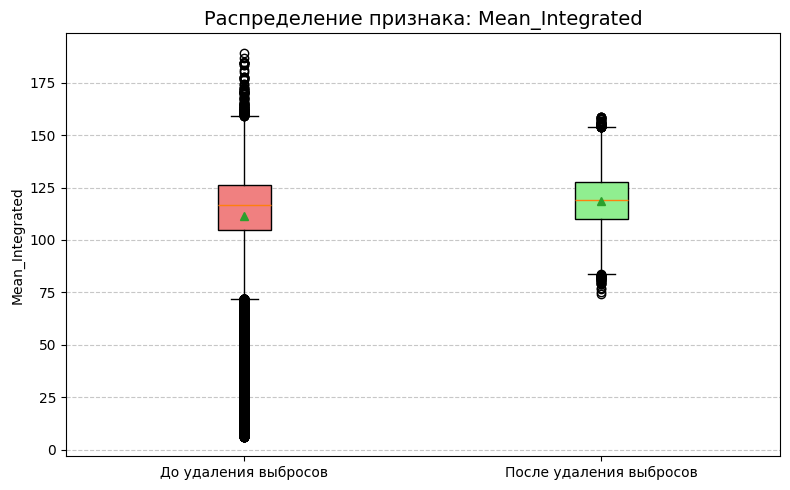

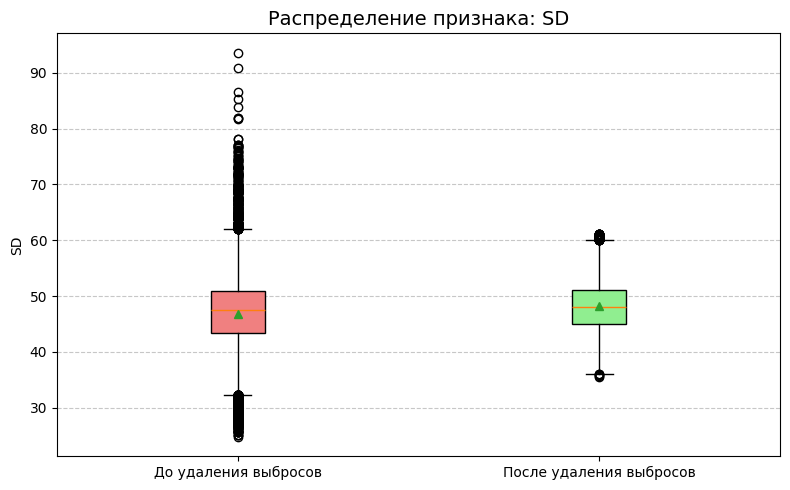

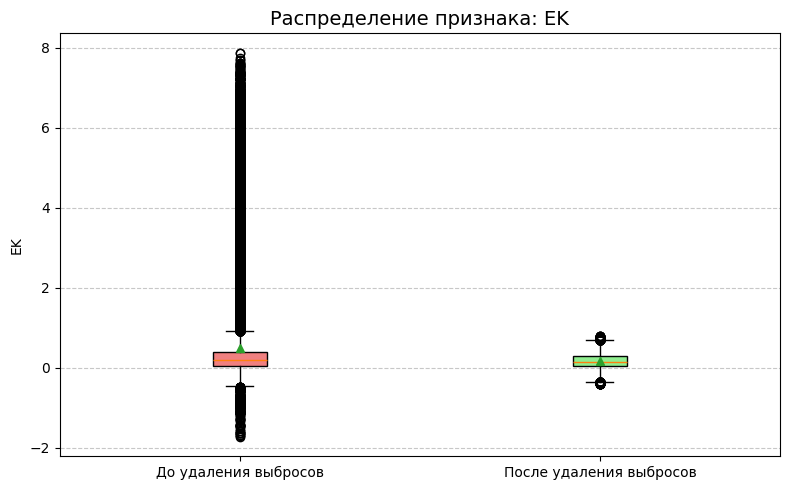

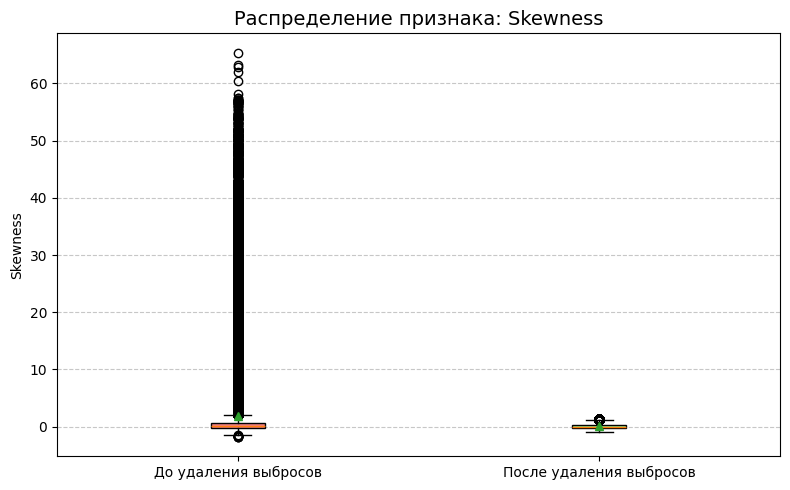

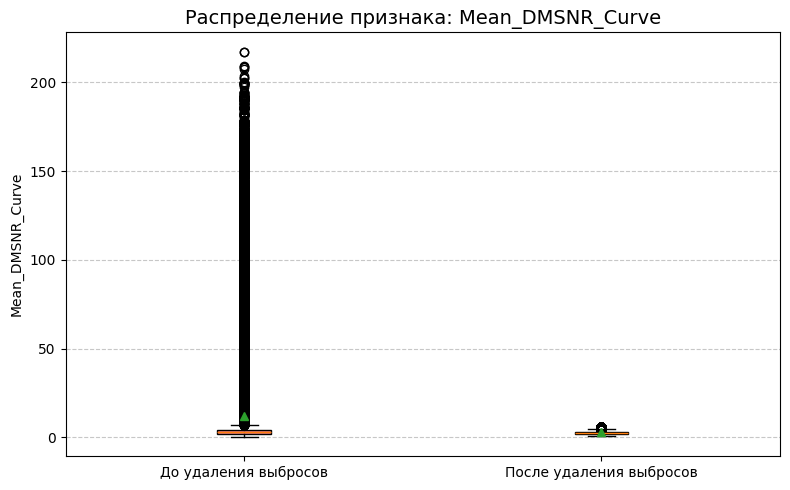

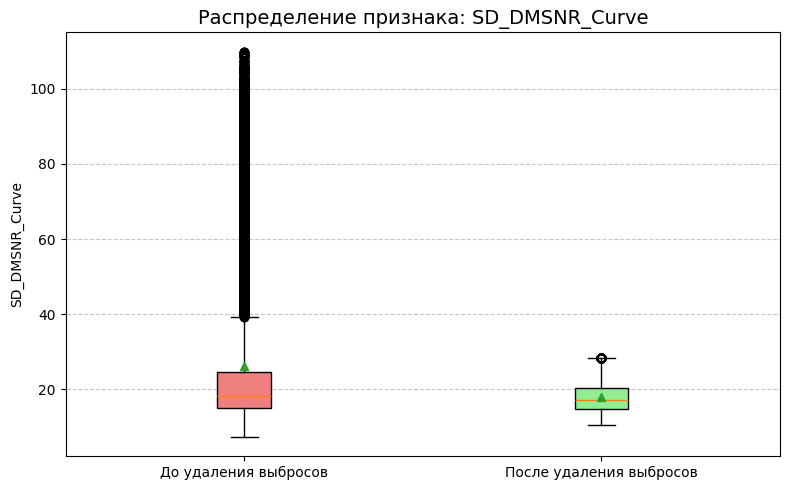

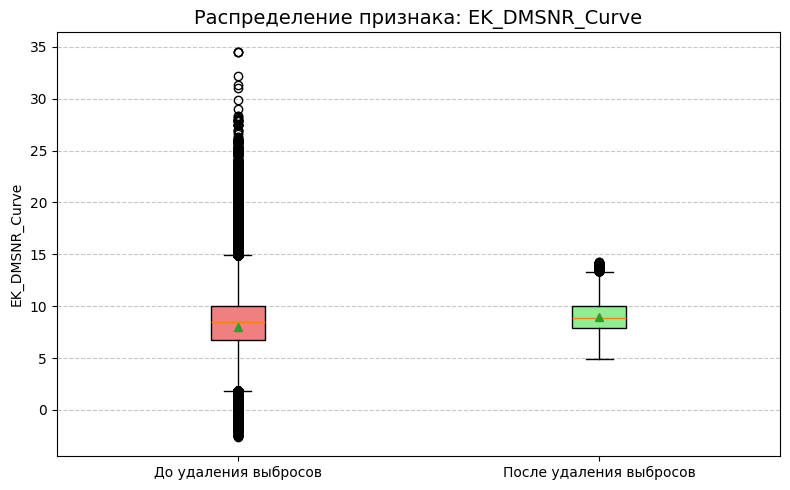

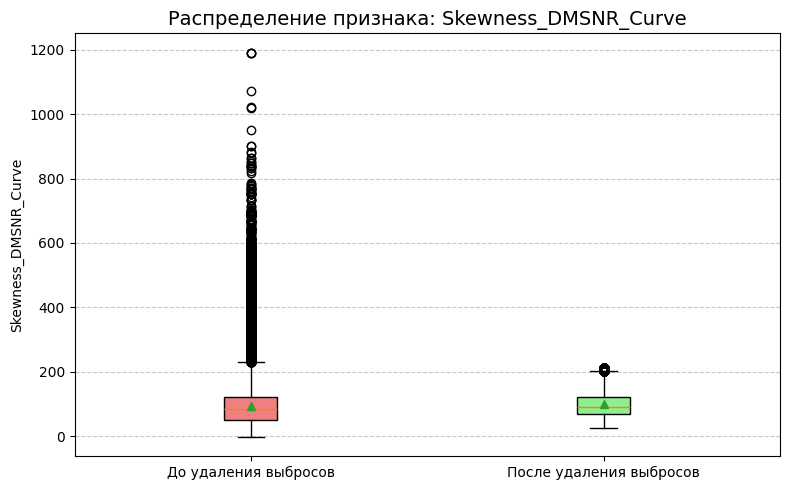

In [15]:
feature_cols = [c for c in train_df.columns if c != 'Class']

for col in feature_cols:
    plt.figure(figsize=(8, 5))

    data_to_plot = [
        train_df[col],
        train_clean[col]
    ]

    bp = plt.boxplot(data_to_plot, tick_labels=['До удаления выбросов', 'После удаления выбросов'],
                     patch_artist=True, showmeans=True)

    colors = ['lightcoral', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.title(f'Распределение признака: {col}', fontsize=14)
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

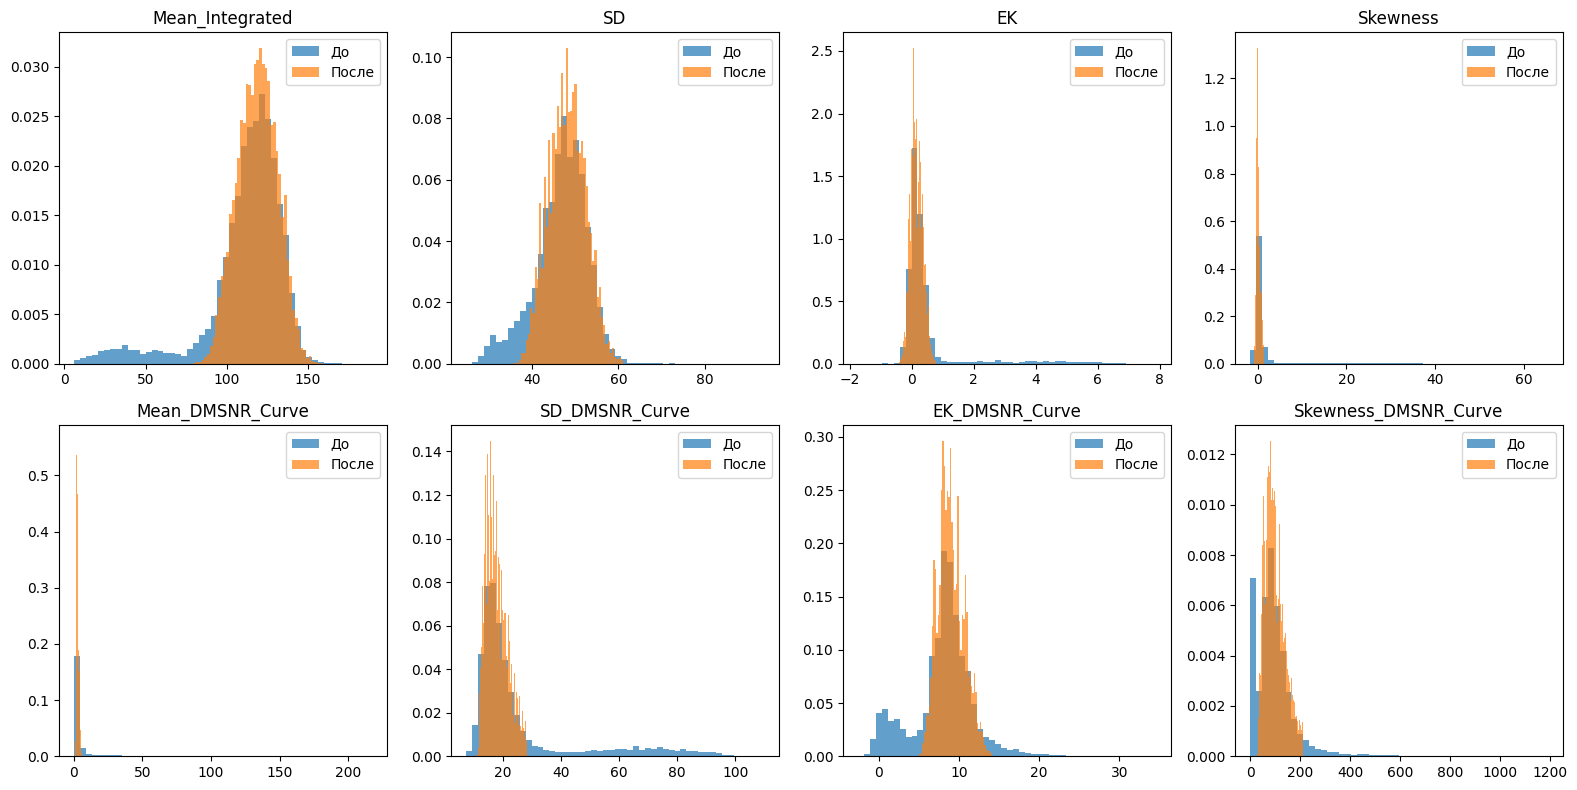

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=50, alpha=0.7, label='До', density=True)
    axes[i].hist(train_clean[col], bins=50, alpha=0.7, label='После', density=True)
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

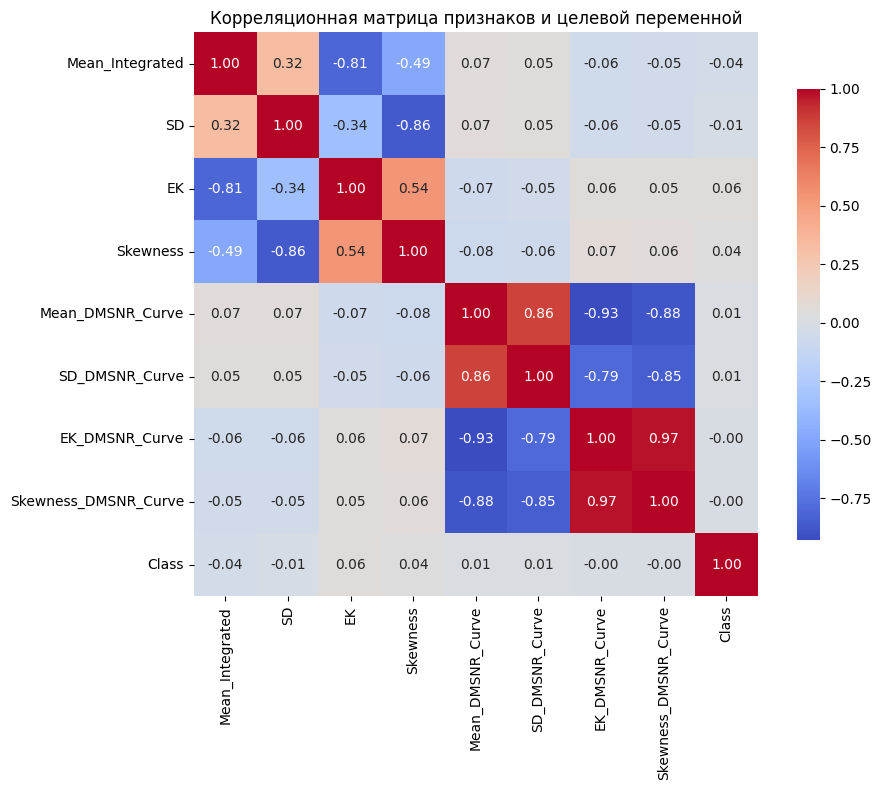

Корреляции признаков с Class:
 Class                   1.000000
EK                      0.057841
Skewness                0.036929
SD_DMSNR_Curve          0.013954
Mean_DMSNR_Curve        0.009266
EK_DMSNR_Curve         -0.004222
Skewness_DMSNR_Curve   -0.004465
SD                     -0.012100
Mean_Integrated        -0.043195
Name: Class, dtype: float64


In [17]:
plt.figure(figsize=(10, 8))
corr = train_clean[feature_cols + ['Class']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": 0.8})
plt.title("Корреляционная матрица признаков и целевой переменной")
plt.tight_layout()
plt.show()

corr_with_target = corr['Class'].sort_values(ascending=False)
print("Корреляции признаков с Class:\n", corr_with_target)

In [18]:
from sklearn.model_selection import train_test_split

X = train_clean.drop(columns=['Class'])
y = train_clean['Class']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train:\n{y_train.value_counts(normalize=True)}")
print(f"Распределение классов в val:\n{y_val.value_counts(normalize=True)}")
print(f"Распределение классов в test:\n{y_test.value_counts(normalize=True)}")

Train: (48292, 8), Val: (16098, 8), Test: (16098, 8)
Распределение классов в train:
Class
0    0.99855
1    0.00145
Name: proportion, dtype: float64
Распределение классов в val:
Class
0    0.998509
1    0.001491
Name: proportion, dtype: float64
Распределение классов в test:
Class
0    0.998509
1    0.001491
Name: proportion, dtype: float64


В качестве главной метрики выбрана LogLoss, так как она непосредственно используется в соревновании Kaggle, штрафует модель за уверенные ошибочные прогнозы и важна для калибровки вероятностей, а не только для ранжирования ответов. Дополнительно применяется ROC‑AUC, которая позволяет оценить разделяющую способность модели вне зависимости от порога и помогает сравнить модели с близкими значениями LogLoss. F1‑score служит для поиска оптимального порога классификации и защищает от иллюзии высокой точности (accuracy) при сильном дисбалансе классов. Precision и Recall используются для полноты анализа: Precision показывает долю истинных пульсаров среди предсказанных (ложные тревоги), а Recall — долю найденных настоящих пульсаров (пропущенные цели). Таким образом, комбинация этих метрик даёт полную картину поведения модели и обоснованный выбор наилучшего решения.

In [21]:
train_clean.to_csv('train_processed.csv', index=False)